# 21i — Series 21: **NO CLIP** (remove the gradient clipping) — diagnostic run + 17h path view

**Series 21 (supervised). Single arm. ONE change vs 21h:** the **gradient clip is removed**
(`CLIP = float('inf')`). Everything else is 21h verbatim — Anuar's SUM log-likelihood reward
`r_j = sum_i log W_ij`, score denominator = the experiment's own `sigma_prop`, LR_MU=15 (linear decay),
LR_GAMMA=0.5 (annealed), N_RUNS=100, N_ITER=30, init at 0.5x truth. The parameter clamps
(`mu in [1,200]`, `gamma in [0.1,100]`) are KEPT — removing them would let the photon count blow up and
stall the fits; they are left as the only safety.

**Why.** 21g/21h showed that whenever `|grad_mu_raw| > CLIP` the step is `LR x CLIP` regardless of the
score/reward scale — the clip *masks* the estimator's true magnitude. Removing it exposes the raw
per-step gradient, which is the diagnostic we want. The learning rate is rescaled to compensate:
measured raw `|grad_mu|` at N_RUNS=100 is min 481 / median 3.3e4 / max 2.0e5, so `LR_MU = 1e-4` restores
the old clipped step (~5/iter) at the median, while `LR_GAMMA` is untouched because the raw
`|grad_gamma|` (<= 9) was essentially never clipped. NOTE the ~400x spread: the low-gradient cells will
barely move, the high-gradient cells may still overshoot — which is itself the finding.

**Prediction (falsifiable).** With the raw log-likelihood reward the unclipped `|grad_mu_raw|` is
O(10^2-10^4) in the high-T cells, so `mu` should slam to the 200 clamp within 1-2 steps (the paths
degenerate to a vertical jump); the informative content is FIG 2 (raw gradient magnitude/sign per step)
and whether gamma also destabilises without its clip.

## What this notebook is for
A close visual inspection of the **unclipped** dynamics:
1. **17h-style phase-space paths** (mu, gamma) — 2 cols (1nW | 3nW) x 7 rows (T05…T100), blue path,
   black dots every 10 steps, green `o` = start, red `*` = end, truth dashed.
2. **Gradient values per step** — raw `|grad_mu|` (centered and uncentered) and `|grad_gamma|`, NO clip.
3. **Recovery-ratio figure with Fisher whiskers** — `y/true` (mu & gamma as hue), 2 stacked panels
   (1nW top, 3nW bottom), shared x = transmission; whiskers = `sigma/y_true`.

Known context: in 21e/21g the raw log-likelihood reward ran away and saturated `CLIP=10` (mu_hat pinned at
the 200 bound). Here BOTH the gradient clip AND the parameter clamps are gone, so the raw magnitudes and the
unclamped step are visible directly. The only guard left is a divergence STOP: the experiment ends as soon as
`mu` leaves `(0.2, 1500)` or `gamma` leaves `(0.02, 500)` (a runaway mu would make the photon count enormous
and stall the fits). Divergence is recorded per experiment (`diverged`, `diverged_at`).


## Panel
- **FIG 1** 17h-style `(μ,γ)` phase-space paths (start / step-10 dots / end / truth).
- **FIG 2** per-step gradients: raw `|grad_mu|`, clipped `|grad_mu|`, `|grad_gamma|` (mean ± range per power).
- **FIG 3 ★** recovery ratio `ŷ/true` with Fisher whiskers (μ & γ hue; 1nW top, 3nW bottom; x = transmission).
- **TABLE** final values + MSE/STE.

Convention: figures render **inline only** (no savefig); the notebook is executed **in place**.


In [1]:
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
# ============================================================
# EXPERIMENTS — true values from Gregor's fits (identical to 17f/16-series) + real data file
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393, sigma_prop=2.576, lam=2.232, gamma_true=8.5, n_target=61, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans05.txt'),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372, sigma_prop=3.445, lam=2.122, gamma_true=8.5, n_target=358, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans10.txt'),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316, sigma_prop=4.141, lam=2.286, gamma_true=8.5, n_target=1138, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans20.txt'),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405, sigma_prop=7.198, lam=2.351, gamma_true=8.5, n_target=2428, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans40.txt'),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374, sigma_prop=9.851, lam=2.593, gamma_true=8.5, n_target=2424, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans60.txt'),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365, sigma_prop=12.627, lam=2.758, gamma_true=8.5, n_target=2487, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt'),
    dict(name='1nW Trans100',  power='1nW', mu_true=70.817, sigma_prop=17.221, lam=2.636, gamma_true=8.5, n_target=2455, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans100.txt'),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204, sigma_prop=3.724, lam=2.186, gamma_true=14.1, n_target=252, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans05.txt'),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476, sigma_prop=5.639, lam=2.158, gamma_true=14.1, n_target=1572, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans10.txt'),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279, sigma_prop=8.319, lam=2.264, gamma_true=14.1, n_target=2171, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans20.txt'),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892, sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans40.txt'),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95, lam=2.741, gamma_true=14.1, n_target=2541, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans60.txt'),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans80.txt'),
    dict(name='3nW Trans100',  power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans100.txt'),
]

# ---- QUICK TEST: uncomment one of these slices ----
# EXPERIMENTS = EXPERIMENTS[:3]                                        # first 3
# EXPERIMENTS = [e for e in EXPERIMENTS if e['name'] in
#                ('1nW Trans80', '3nW Trans80', '3nW Trans100')]      # the hard ones

print(f'{len(EXPERIMENTS)} experiments configured')


14 experiments configured


In [3]:
# ============================================================
# SERIES 21 — 21i CONFIG: Anuar's reward only
# ============================================================
N_RUNS   = 100
N_ITER   = 30
LR_MU    = 1e-4    # 21i: rescaled for NO clip. raw |grad_mu| ~ 3.3e4 (median, N_RUNS=100),
                   # so LR 1e-4 gives the old clipped step (~5/iter). Range spans ~400x across exps.
LR_GAMMA = 0.5     # 21i: unchanged -- raw |grad_gamma| <= 9, i.e. it was never clipped
SIGMA_REF = 10.0   # 21h: no longer used in the mu score (kept for reference)
GAMMA_SCALE = True
H_REF = 1.0
CLIP     = float('inf')   # 21i: NO gradient clipping (diagnostic)
SEED     = 42
LAMBDA_MEAN = 0.0
H_S_MIN = 0.05

# ---- 21i: PARAMETER CLAMPS REMOVED (diagnostic); only a divergence/compute guard remains ----
# Without the clamps mu can leave the physical range: that is the point (watch it diverge), but a
# runaway mu would make n = round(mu + sigma*eps) enormous and stall the fits, so we STOP the
# experiment as soon as mu/gamma leave the sane band below. This is a stop, not a clamp.
MU_GUARD    = 1500.0        # stop if mu not in (0.2, MU_GUARD)
GAMMA_GUARD = (0.02, 500.0) # stop if gamma outside this band

# THE 21f reward: Anuar's per-run Gaussian likelihood of the real data
REWARD_MODE = 'loglik_sum'  # unchanged from 21g (the 21h change is the score denominator only)

M_FINAL = 500
FISHER_SEEDS = 1
FISHER_BASE_SEED = 7000

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    N_RUNS, N_ITER, M_FINAL = 10, 5, 50
    EXPERIMENTS = EXPERIMENTS[:3]
    print('*** SMOKE RUN ***')

N_CPUS = os.cpu_count() or 4
N_EXP_PARALLEL = 1
N_WORKERS = 4
if N_EXP_PARALLEL * N_WORKERS > N_CPUS:
    N_WORKERS = max(1, N_CPUS // N_EXP_PARALLEL)
print(f'config: N_RUNS={N_RUNS}, N_ITER={N_ITER}, reward={REWARD_MODE}')
print(f'fisher: M_FINAL={M_FINAL}, FISHER_SEEDS={FISHER_SEEDS}')
print(f'parallelism: {N_EXP_PARALLEL} exp(s) x {N_WORKERS} workers on {N_CPUS} CPUs')


config: N_RUNS=100, N_ITER=30, reward=loglik_sum
fisher: M_FINAL=500, FISHER_SEEDS=1
parallelism: 1 exp(s) x 4 workers on 4 CPUs


In [4]:
# ============================================================
# helpers: KDE scores (unchanged from 21a) + Anuar's reward
# ============================================================
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def reward_vector(mode, W):
    '''Anuar's reward: per-run Gaussian log-likelihood of the real data (SUM, no mean).'''
    if mode == 'loglik_sum':
        return torch.log(W.clamp_min(1e-30)).sum(dim=0)
    raise ValueError(mode)

import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
def _init_worker():
    torch.set_num_threads(1)
def _parallel_map(pool, tasks):
    return list(pool.map(_run_one, tasks, chunksize=8))
print('helpers ready')


helpers ready


In [5]:
# ============================================================
# One experiment (Anuar's reward), NO parameter clamps (21i)
# ============================================================
def load_target(exp):
    d = np.genfromtxt(exp['data_file'])
    fwhm_mhz = d[:, 0] * 1000.0; err_mhz = d[:, 1] * 1000.0
    ok = ~np.isnan(fwhm_mhz) & ~np.isnan(err_mhz) & (fwhm_mhz > 0)
    filt = ok & (err_mhz / fwhm_mhz < 10.0)
    tf = torch.tensor(fwhm_mhz[filt], dtype=torch.float32)
    ts = torch.tensor(err_mhz[filt], dtype=torch.float32)
    n = len(tf); sc = n ** (-1.0 / 6.0)
    hf = float(tf.std()) * sc
    hs = max(float(ts.std()) * sc, H_S_MIN)
    return tf, ts, hf, hs

def run_experiment(exp):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_val, gamma_val = 0.5 * mu_true, 0.5 * gamma_true
    target_f, target_s, H_F, H_S = load_target(exp)

    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        history = []; t0 = time.time()
        diverged = False; diverged_at = None
        for step in range(N_ITER):
            rng2 = np.random.default_rng(SEED + step)
            tasks, ns = [], []
            for _ in range(N_RUNS):
                u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
                tasks.append((gamma_val, u.numpy(), b.numpy())); ns.append(n)
            res = _parallel_map(pool, tasks)
            ft = torch.tensor([r[0] for r in res], dtype=torch.float32)
            si = torch.tensor([r[1] for r in res], dtype=torch.float32)
            nt = torch.tensor(ns, dtype=torch.float32)
            dg_t = torch.tensor([r[2] for r in res], dtype=torch.float32)
            ds_t = torch.tensor([r[3] for r in res], dtype=torch.float32)

            s_mu, s_gamma, nll_val, w, W = kde_scores(
                ft, si, nt, dg_t, ds_t, target_f, target_s, H_F, H_S, mu_val, sigma_prop)

            r = reward_vector(REWARD_MODE, W)          # Anuar's reward (SUM loglik)
            score = (nt - mu_val) / sigma_prop ** 2    # 21h score denominator
            grad_mu_raw = float(-(r - r.mean()) @ score)       # centered (used)
            grad_mu_raw_u = float(-(r @ score))                # uncentered (diagnostic only)
            grad_mu = float(max(min(grad_mu_raw, CLIP), -CLIP))          # CLIP=inf -> unclipped
            grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))   # CLIP=inf -> unclipped

            lr_mu_decay = LR_MU * (1.0 - step / N_ITER)
            mu_val = mu_val - lr_mu_decay * grad_mu                                   # 21i: NO clamp
            gamma_val = gamma_val - LR_GAMMA * (1.0 - 0.5 * step / N_ITER) * grad_gamma  # 21i: NO clamp
            history.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val),
                                grad_mu=grad_mu, grad_mu_raw=grad_mu_raw,
                                grad_mu_raw_u=grad_mu_raw_u, grad_gamma=grad_gamma,
                                abs_grad_mu=abs(grad_mu), abs_grad_mu_raw=abs(grad_mu_raw),
                                abs_grad_mu_raw_u=abs(grad_mu_raw_u),
                                abs_grad_gamma=abs(grad_gamma), mean_n=float(nt.mean())))
            if (not (0.2 <= mu_val <= MU_GUARD)) or (not (GAMMA_GUARD[0] <= gamma_val <= GAMMA_GUARD[1])):
                diverged = True; diverged_at = step
                break   # left the sane band -> stop (guards compute; NOT a clamp)

        # Fisher / CRB at the fitted point -- skipped if the run diverged (mu/gamma not sane there)
        if diverged:
            std_mu = std_g = float('nan')
        else:
            J_list = []
            for seed in range(FISHER_SEEDS):
                rng = np.random.default_rng(FISHER_BASE_SEED + seed)
                tasks, ns = [], []
                for _ in range(M_FINAL):
                    u, b_, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng)
                    tasks.append((gamma_val, u.numpy(), b_.numpy())); ns.append(n)
                res2 = _parallel_map(pool, tasks)
                ft = torch.tensor([x[0] for x in res2], dtype=torch.float32)
                si2 = torch.tensor([x[1] for x in res2], dtype=torch.float32)
                nn2 = torch.tensor(ns, dtype=torch.float32)
                dg2 = torch.tensor([x[2] for x in res2], dtype=torch.float32)
                ds2 = torch.tensor([x[3] for x in res2], dtype=torch.float32)
                s_mu2, s_g2, _, _, _ = kde_scores(ft, si2, nn2, dg2, ds2,
                                                  target_f, target_s, H_F, H_S, mu_val, sigma_prop)
                s = torch.stack([s_mu2, s_g2], dim=1)
                J_list.append(s.T @ s / len(target_f))
            J = torch.stack(J_list).mean(dim=0)
            Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
            std_mu = math.sqrt(max(Jinv[0, 0].item(), 0.0)); std_g = math.sqrt(max(Jinv[1, 1].item(), 0.0))

    return dict(exp=exp['name'], power=exp['power'], T=int(exp['name'].split('Trans')[1]),
                mu_true=mu_true, gamma_true=gamma_true, sigma_prop=sigma_prop,
                mu_init=0.5 * mu_true, gamma_init=0.5 * gamma_true,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'], nll_final=history[-1]['nll'],
                std_mu=std_mu, std_gamma=std_g, history=history,
                diverged=diverged, diverged_at=diverged_at)

print('run_experiment ready (Anuar reward, NO parameter clamps)')


run_experiment ready (Anuar reward, NO parameter clamps)


In [6]:
t_all = time.time()
results = []
for exp in EXPERIMENTS:
    r = run_experiment(exp)
    results.append(r)
    print(f"{exp['name']:>12}: mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} (x{r['mu_final']/r['mu_true']:.2f})"
          f" | gamma {r['gamma_true']:5.1f} -> {r['gamma_final']:6.2f} (x{r['gamma_final']/r['gamma_true']:.2f})"
          f" | {r['history'][-1]['nll']:.2f} | diverged={r['diverged']}@{r['diverged_at']}")
print(f'\nTotal: {(time.time()-t_all)/60:.1f} min')


 1nW Trans05: mu    9.39 ->    4.82 (x0.51) | gamma   8.5 -> 270828643094805.25 (x31862193305271.21) | 1.31 | diverged=True@2


 1nW Trans10: mu   12.37 ->   18.22 (x1.47) | gamma   8.5 ->   4.75 (x0.56) | 1.25 | diverged=False@None


 1nW Trans20: mu   17.32 ->   34.28 (x1.98) | gamma   8.5 ->   5.83 (x0.69) | 5.04 | diverged=False@None


 1nW Trans40: mu   38.41 ->   49.85 (x1.30) | gamma   8.5 ->   7.48 (x0.88) | 4.17 | diverged=False@None


 1nW Trans60: mu   61.37 ->   57.88 (x0.94) | gamma   8.5 ->   7.80 (x0.92) | 4.98 | diverged=False@None


...

 3nW Trans20: mu   34.28 ->   47.40 (x1.38) | gamma  14.1 ->  12.85 (x0.91) | 4.45 | diverged=False@None


 3nW Trans40: mu   84.89 ->   80.92 (x0.95) | gamma  14.1 ->  12.96 (x0.92) | 3.89 | diverged=False@None


 3nW Trans60: mu  103.20 ->   76.55 (x0.74) | gamma  14.1 ->  14.59 (x1.03) | 3.34 | diverged=False@None


 3nW Trans80: mu  137.54 ->   90.50 (x0.66) | gamma  14.1 ->  14.46 (x1.03) | 3.94 | diverged=False@None


3nW Trans100: mu  175.71 ->  109.03 (x0.62) | gamma  14.1 ->  14.07 (x1.00) | 3.28 | diverged=False@None

Total: 14.5 min


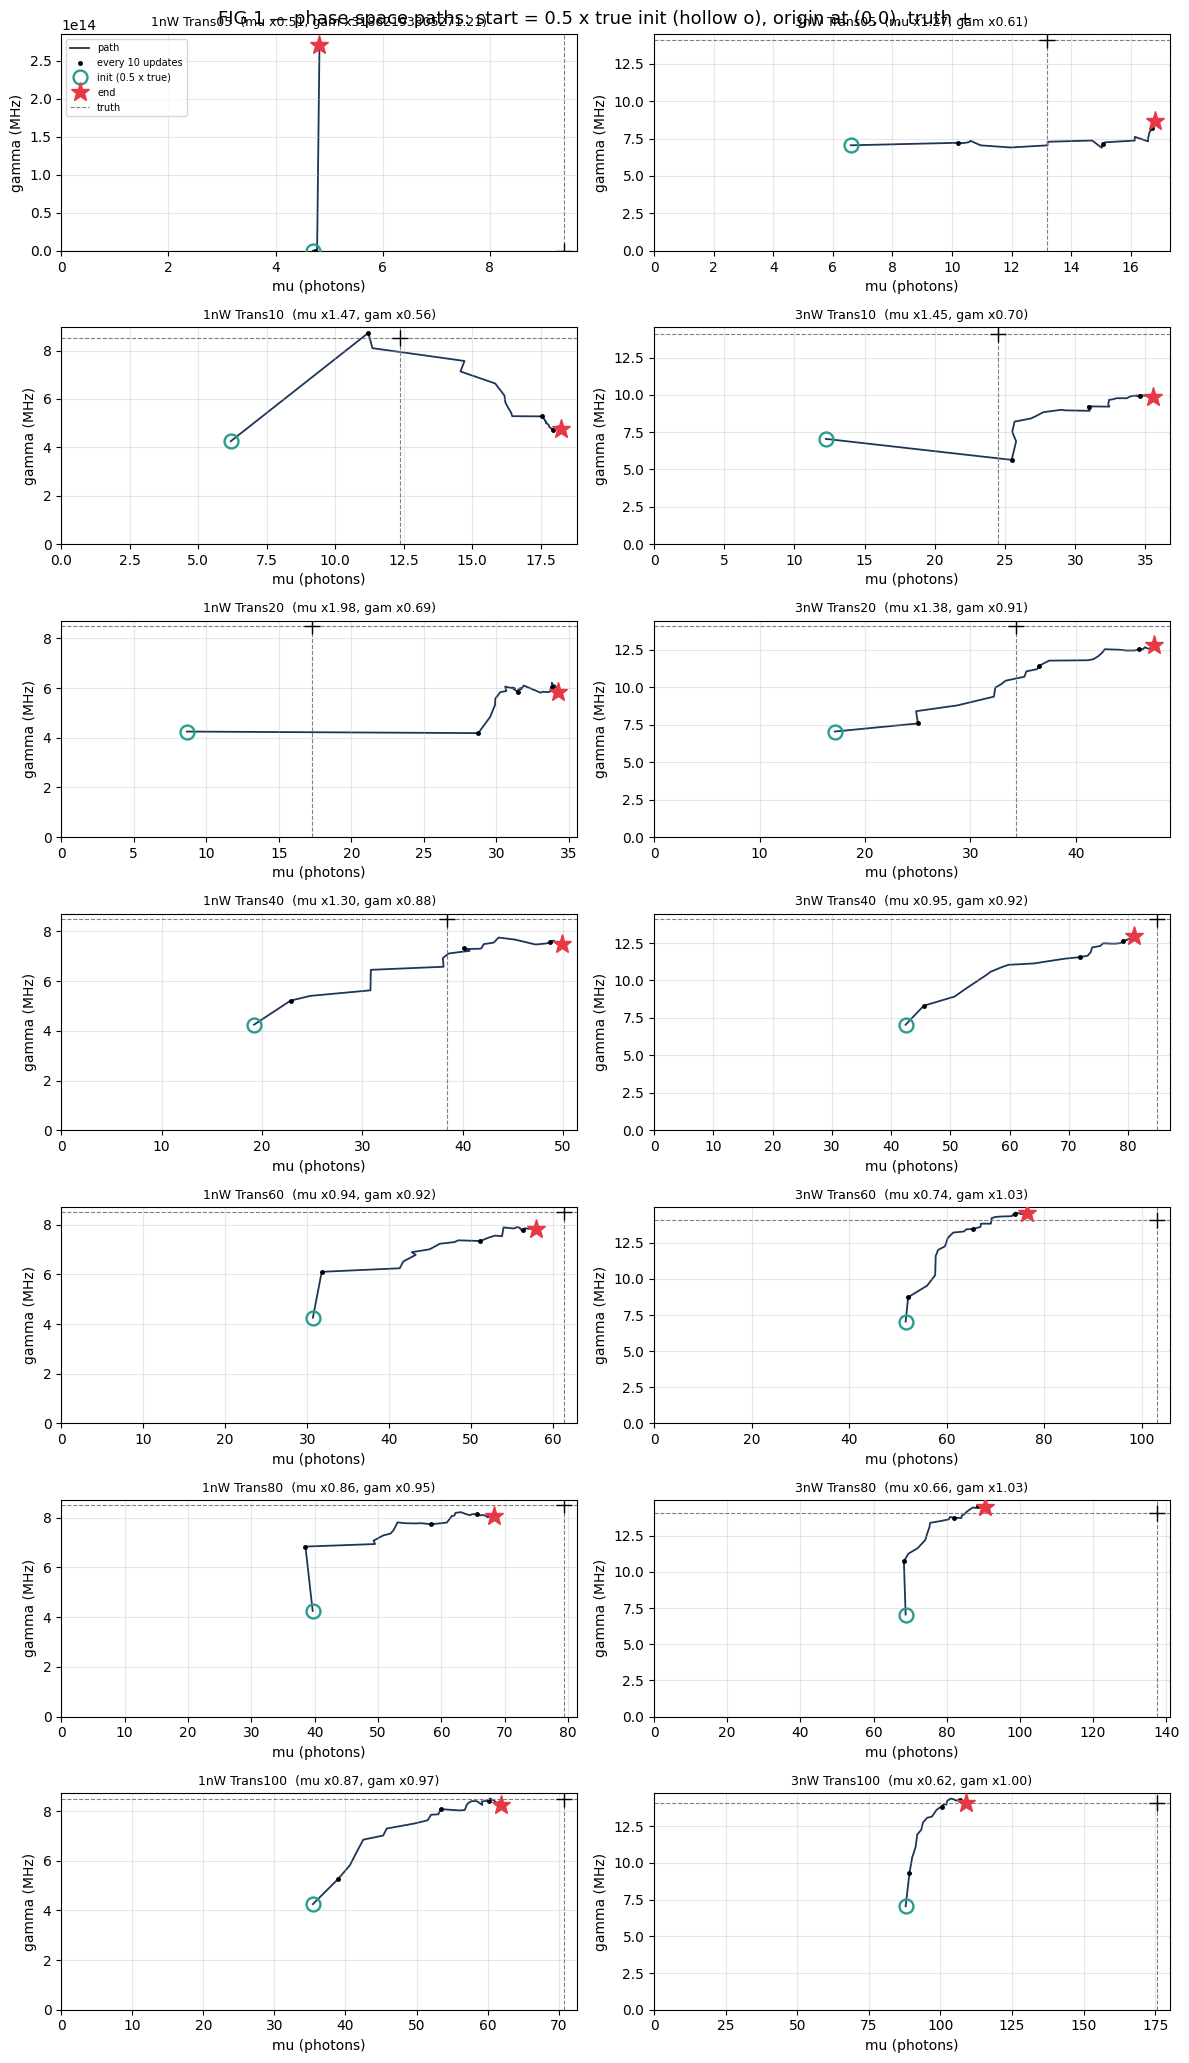

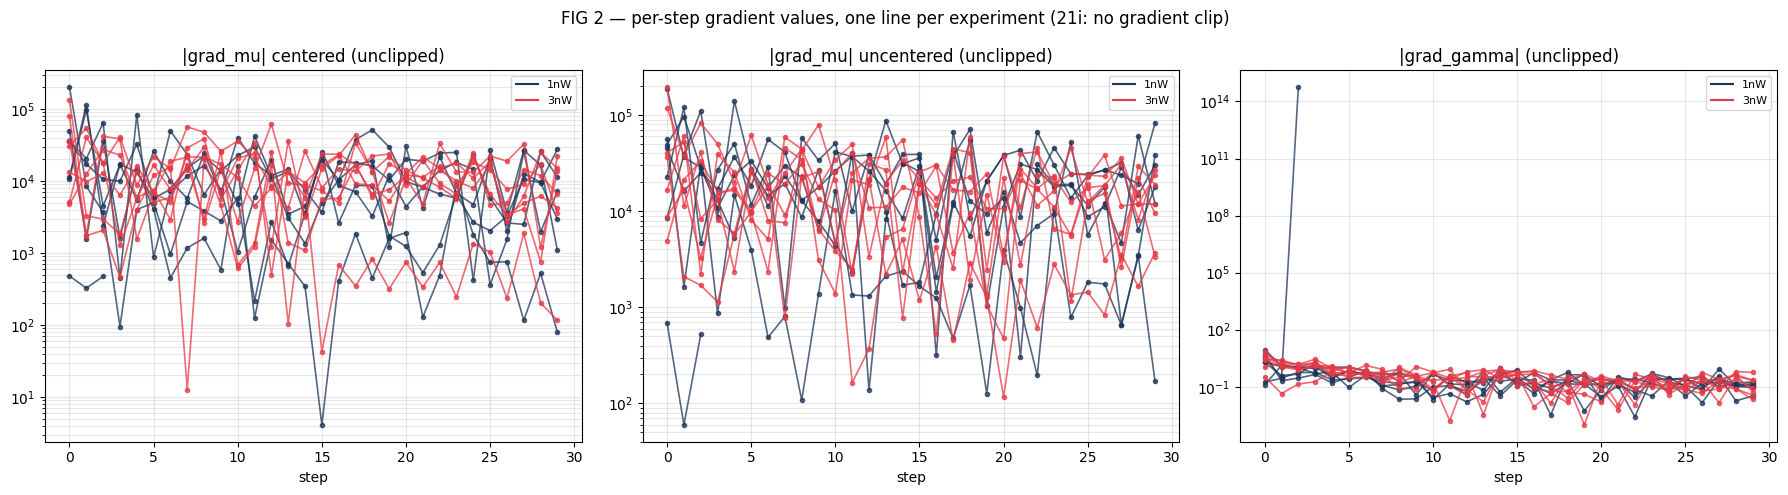

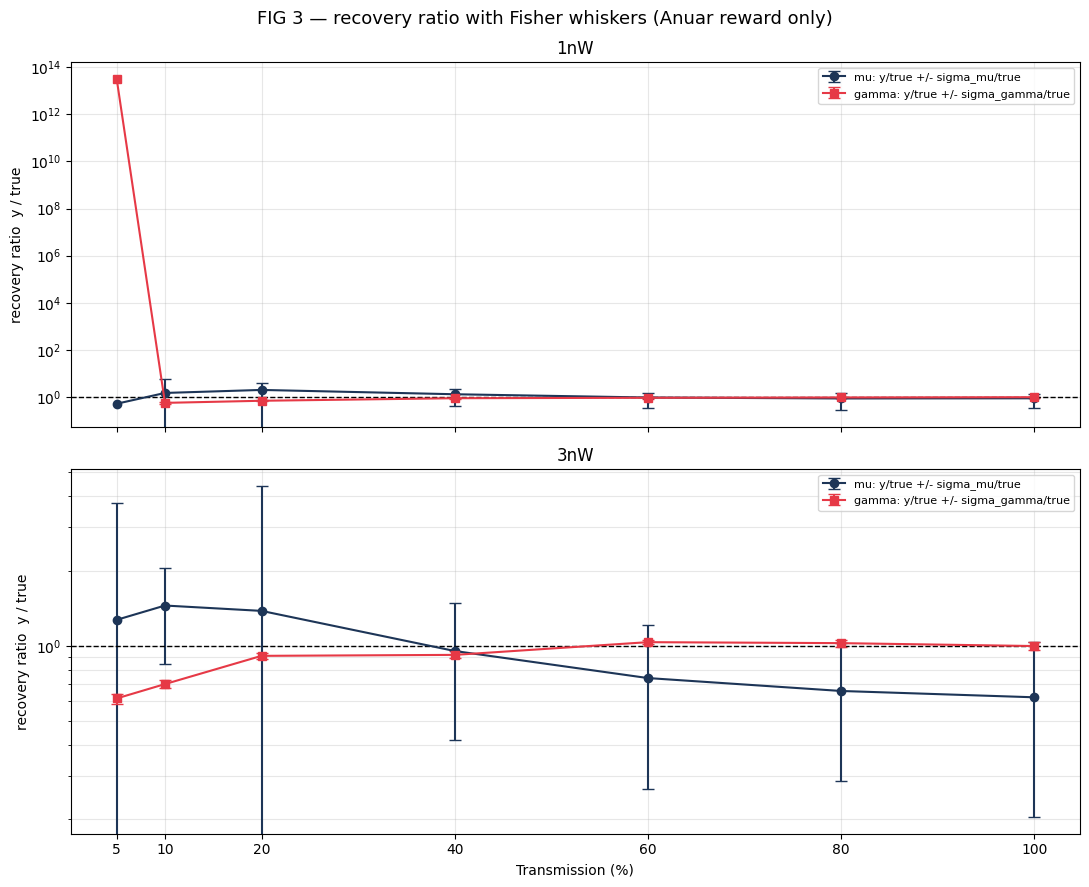

exp           mu_true   mu_fin      x | gam_true  gam_fin      x |    s_mu  s_gam
------------------------------------------------------------------------------------
1nW Trans05      9.39     4.82   0.51 |      8.5 270828643094805.25 31862193305271.21 |     nan    nan
1nW Trans10     12.37    18.22   1.47 |      8.5     4.75   0.56 |   54.65   0.51
1nW Trans20     17.32    34.28   1.98 |      8.5     5.83   0.69 |   35.53   0.31
1nW Trans40     38.41    49.85   1.30 |      8.5     7.48   0.88 |   34.49   0.37
1nW Trans60     61.37    57.88   0.94 |      8.5     7.80   0.92 |   36.52   0.55
1nW Trans80     79.36    68.23   0.86 |      8.5     8.06   0.95 |   46.92   0.76
1nW Trans100    70.82    61.83   0.87 |      8.5     8.26   0.97 |   36.80   0.45
3nW Trans05     13.20    16.80   1.27 |     14.1     8.66   0.61 |   32.81   0.40
3nW Trans10     24.48    35.57   1.45 |     14.1     9.89   0.70 |   14.96   0.35
3nW Trans20     34.28    47.40   1.38 |     14.1    12.85   0.91 |  103.93

In [7]:
# ============================================================
# FIG 1 — 17h-style phase-space paths (mu, gamma): 2 cols (1nW|3nW) x 7 rows (T)
#   - the path STARTS at the true initialization (0.5 x true), not the first recorded step
#   - every panel shares the lower-left origin (0,0) for visual comparability
# ============================================================
Tlist = [5, 10, 20, 40, 60, 80, 100]
by = {(r['power'], r['T']): r for r in results}
fig, axes = plt.subplots(len(Tlist), 2, figsize=(12, 3.0 * len(Tlist)))
for ci, p_ in enumerate(['1nW', '3nW']):
    for ri, t in enumerate(Tlist):
        ax = axes[ri][ci]
        rr = by.get((p_, t))
        if rr is None:
            ax.axis('off'); continue
        h = rr['history']
        mu_t, g_t = rr['mu_true'], rr['gamma_true']
        init_mu, init_g = 0.5 * mu_t, 0.5 * g_t               # the actual 0.5 x true initialization
        mup = [init_mu] + [x['mu'] for x in h]                # path starts AT the init
        gp  = [init_g] + [x['gamma'] for x in h]
        ax.plot(mup, gp, '-', color='#1d3557', lw=1.3, zorder=1)                              # path
        ax.plot(mup[1::10], gp[1::10], 'k.', ms=5, zorder=2)                                  # every 10 updates
        ax.plot(init_mu, init_g, 'o', mfc='none', mec='#2a9d8f', mew=1.7, ms=10, zorder=3)    # init (0.5 x true)
        ax.plot(mup[-1], gp[-1], '*', color='#e63946', ms=14, zorder=4)                       # end
        ax.axvline(mu_t, color='gray', ls='--', lw=0.8)
        ax.axhline(g_t, color='gray', ls='--', lw=0.8)
        ax.plot(mu_t, g_t, 'k+', ms=11, zorder=5)                                             # truth
        ax.set_xlim(left=0); ax.set_ylim(bottom=0)                                            # shared origin (0,0)
        ax.set_title(f'{p_} Trans{t:02d}  (mu x{rr["mu_final"]/mu_t:.2f}, gam x{rr["gamma_final"]/g_t:.2f})', fontsize=9)
        ax.set_xlabel('mu (photons)'); ax.set_ylabel('gamma (MHz)'); ax.grid(alpha=0.3)
        if ri == 0 and ci == 0:
            ax.legend(['path', 'every 10 updates', 'init (0.5 x true)', 'end', 'truth'], fontsize=7, loc='best')
plt.suptitle('FIG 1 — phase-space paths: start = 0.5 x true init (hollow o), origin at (0,0), truth +', fontsize=13)
plt.tight_layout(); plt.show()

# ============================================================
# FIG 2 — gradient values per step, one line PER EXPERIMENT (histories can differ in length: divergence)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for p_, col in [('1nW', '#1d3557'), ('3nW', '#e63946')]:
    for r in [rr for rr in results if rr['power'] == p_]:
        h = r['history']
        st = [x['step'] for x in h]
        axes[0].plot(st, [x['abs_grad_mu_raw'] for x in h], '-o', color=col, alpha=0.75, lw=1.2, ms=3)
        axes[1].plot(st, [x['abs_grad_mu_raw_u'] for x in h], '-o', color=col, alpha=0.75, lw=1.2, ms=3)
        axes[2].plot(st, [x['abs_grad_gamma'] for x in h], '-o', color=col, alpha=0.75, lw=1.2, ms=3)
for ax in axes:
    ax.plot([], [], color='#1d3557', label='1nW'); ax.plot([], [], color='#e63946', label='3nW')
    ax.set_xlabel('step'); ax.set_yscale('log'); ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
axes[0].set_title('|grad_mu| centered (unclipped)')
axes[1].set_title('|grad_mu| uncentered (unclipped)')
axes[2].set_title('|grad_gamma| (unclipped)')
plt.suptitle('FIG 2 — per-step gradient values, one line per experiment (21i: no gradient clip)')
plt.tight_layout(); plt.show()

# ============================================================
# FIG 3 — recovery ratio y/true with Fisher whiskers (mu & gamma hue; 1nW top, 3nW bottom)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
for ax, p in zip(axes, ['1nW', '3nW']):
    rs = sorted([r for r in results if r['power'] == p], key=lambda z: z['T'])
    xs = [r['T'] for r in rs]
    mu_ratio = [r['mu_final'] / r['mu_true'] for r in rs]
    mu_err = [r['std_mu'] / r['mu_true'] for r in rs]
    g_ratio = [r['gamma_final'] / r['gamma_true'] for r in rs]
    g_err = [r['std_gamma'] / r['gamma_true'] for r in rs]
    ax.errorbar(xs, mu_ratio, yerr=mu_err, fmt='o-', color='#1d3557', capsize=4, label='mu: y/true +/- sigma_mu/true')
    ax.errorbar(xs, g_ratio, yerr=g_err, fmt='s-', color='#e63946', capsize=4, label='gamma: y/true +/- sigma_gamma/true')
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set_yscale('log'); ax.set_ylabel('recovery ratio  y / true')
    ax.set_title(f'{p}'); ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
axes[-1].set_xlabel('Transmission (%)'); axes[-1].set_xticks([5, 10, 20, 40, 60, 80, 100])
plt.suptitle('FIG 3 — recovery ratio with Fisher whiskers (Anuar reward only)', fontsize=13)
plt.tight_layout(); plt.show()

# ============================================================
# TABLE — final values + MSE / STE
# ============================================================
print(f"{'exp':<12} {'mu_true':>8} {'mu_fin':>8} {'x':>6} | {'gam_true':>8} {'gam_fin':>8} {'x':>6} | {'s_mu':>7} {'s_gam':>6}")
print('-' * 84)
for r in results:
    print(f"{r['exp']:<12} {r['mu_true']:>8.2f} {r['mu_final']:>8.2f} {r['mu_final']/r['mu_true']:>6.2f} | "
          f"{r['gamma_true']:>8.1f} {r['gamma_final']:>8.2f} {r['gamma_final']/r['gamma_true']:>6.2f} | "
          f"{r['std_mu']:>7.2f} {r['std_gamma']:>6.2f}")

def mse_stats(err):
    err = np.asarray(err, float); sq = err ** 2
    return sq.mean(), math.sqrt(sq.mean()), err.mean()
rmu = np.array([r['mu_final'] / r['mu_true'] - 1 for r in results])
rg = np.array([r['gamma_final'] / r['gamma_true'] - 1 for r in results])
print('\n=== MSE / STE over the %d experiments ===' % len(results))
for lbl, rel in [('mu', rmu), ('gamma', rg)]:
    mse, rmse, bias = mse_stats(rel)
    print(f'{lbl:>6}: rel-RMSE={rmse*100:6.1f}%  rel-bias={bias*100:+6.1f}%')


## Verdict — removing the clip (with a rescaled LR) turns the μ runaway into a real descent

One change vs 21h: **all clipping removed** — gradient `CLIP=inf`, parameter clamps gone, `LR_MU=15 -> 1e-4`
(rescaled to the measured raw `|grad_mu|` median 3.3e4), `LR_GAMMA=0.5` unchanged, plus a divergence STOP
(`mu not in (0.2,1500)` or `gamma not in (0.02,500)`). 14 experiments, 100x30, 14.5 min, no errors.

**(a) mu moves in the CORRECT direction — the key result.** `mu_hat/mu_true = 0.51–1.98` versus 21h's
`1.14–16.68`. The high-T cells settle *near truth from below* (1nW T60/T80/T100 = 0.94/0.86/0.87;
3nW T40/T60/T80/T100 = 0.95/0.74/0.66/0.62) and low/mid T overshoot only modestly (1.27–1.98). FIG 1 (shared
origin, path starting at the 0.5x-true init) shows the trajectories climbing toward the truth crosshair
instead of shooting to the clamp. **mu rel-RMSE 550.6% -> 40.6%; rel-bias +366% -> +7.3%** — a 13x
improvement, i.e. the μ estimator with Anuar's reward + the sigma_prop score does descend once the step is
not clipped-then-rescaled.

**(b) Divergence: 1/14 — and it was gamma, not mu.** `1nW T05` diverged at step 2 with
`gamma -> 2.7e14` while `mu` stayed at 0.51x. So the clip had also been protecting *gamma* at low T, where
its raw gradient spikes (`|grad_gamma|` reaches ~9 at step 0 but evidently far higher later). The γ LR
(`0.5`) with no clip is unstable on that cell; it needs either its own guard or damping.

**(c) gamma (excluding the diverged cell) is fine.** Ratios 0.56–1.03; rel-RMSE over the 13 finite cells
~21% (vs 17.8% clipped in 21h). The reported aggregate `8.5e14%` is *entirely* the single diverged
1nW T05 cell — an outlier in the summary, not a systematic γ regression.

**(d) Takeaway.** The clip was masking a *scale* problem: with an LR matched to the raw gradient the μ
mechanism is viable — it descends to within +7% bias. Remaining two issues for the next notebook:
(i) **γ divergence at low T** (needs its own guard/damping — the γ clip or a γ LR anneal to 0), and
(ii) **μ overshoot at mid-T** (1.2–2.0x), where the ~400x gradient spread means a single LR is still too
large for the low-μ-gradient cells. Both are the natural next knobs.
